# Imports

In [126]:
%load_ext autoreload
%autoreload 2

import config
import coords

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger(__name__)

logger.info("Loading imports...")

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# File management
import sys

# Data anaylsis
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)
from scipy.stats import t

# Plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
plt.rcParams['mathtext.fontset'] = 'dejavusans'
import string

# Auxiliary functions
# sys.path.insert(0, "/glade/u/home/sressel/thesis-work/python/auxiliary_functions/")
from load_aquaplanet_data import load_multi_experiment_processed_data
from auxiliary_functions import xarray_utils
from auxiliary_functions.plotting_utils import bmh_colors, tick_labeller, set_plot_mode, get_figsize
logger.info("Imports loaded")


2026-05-08 10:10:07,021 [INFO] Loading imports...
2026-05-08 10:10:07,022 [INFO] Imports loaded


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

In [2]:
variables_to_load = [
    "Precipitation",
    "Outgoing Longwave Radiation",
    # "Zonal Wind",
    # "Meridional Wind",
    # "Vertical Wind",
    # "Divergence",
    "Temperature",
    # "Moisture",
    # "Relative Humidity",
    # "Geopotential Height",
    # "Longwave Heating Rate",
    # "Shortwave Heating Rate",
    # "Latent Heat Flux",
    # "Sensible Heat Flux",
    # "Surface Pressure",
    # "Moist Static Energy",
    # "Dry Static Energy",
    # "Column Moist Static Energy",
    "Column Water Vapor",
    # "Column Temperature",
    # "Column Longwave Heating",
    # "Column Shortwave Heating",
    # "Potential Temperature",
    # "Saturation Specific Humidity"
    # "Column Relative Humidity",
    # "Diabatic Heating",
    # "Chikira alpha"
    # "Surface Longwave Flux",
    # "Surface Shortwave Flux",
    # "TOA Longwave Flux",
    # "TOA Shortwave Flux",
    # "Net Longwave Flux",
    # "Net Shortwave Flux",
    "Cloud Ice Water Content",
    "Cloud Liquid Water Content",
    "Cloud Fraction"
]

logger.info("Variables to Load:")
logger.info([f"{variable}" for variable in variables_to_load])

2026-05-08 08:49:55,073 [INFO] Variables to Load:
2026-05-08 08:49:55,074 [INFO] ['Precipitation', 'Outgoing Longwave Radiation', 'Temperature', 'Column Water Vapor', 'Cloud Ice Water Content', 'Cloud Liquid Water Content', 'Cloud Fraction']


## Subset data

In [3]:
# Check if the subset has already been loaded
if not 'multi_experiment_variables_subset' in locals():
    # If not loaded yet, load the multi-experiment data with variables subset
    multi_experiment_variables_subset = load_multi_experiment_processed_data(
        variables_to_load,
        'subset'
    )
else:
    # If already loaded, reload the data while preserving the existing subset
    # and pass False to prevent overwriting
    multi_experiment_variables_subset = load_multi_experiment_processed_data(
        variables_to_load,
        'subset',
        multi_experiment_variables_subset,
        False
    )

2026-05-08 08:49:58,034 [INFO] Loading subset data
2026-05-08 08:49:58,041 [INFO] (1/7) Precipitation...
2026-05-08 08:49:58,043 [INFO]     Experiment: -4K...


2026-05-08 08:49:58,097 [INFO]     Experiment: 0K...
2026-05-08 08:49:58,189 [INFO]     Experiment: 4K...
2026-05-08 08:49:58,914 [INFO] (2/7) Outgoing Longwave Radiation...
2026-05-08 08:49:58,915 [INFO]     Experiment: -4K...
2026-05-08 08:49:58,982 [INFO]     Experiment: 0K...
2026-05-08 08:49:59,091 [INFO]     Experiment: 4K...
2026-05-08 08:49:59,491 [INFO] (3/7) Temperature...
2026-05-08 08:49:59,493 [INFO]     Experiment: -4K...
2026-05-08 08:49:59,563 [INFO]     Experiment: 0K...
2026-05-08 08:49:59,636 [INFO]     Experiment: 4K...
2026-05-08 08:50:13,279 [INFO] (4/7) Column Water Vapor...
2026-05-08 08:50:13,280 [INFO]     Experiment: -4K...
2026-05-08 08:50:13,469 [INFO]     Experiment: 0K...
2026-05-08 08:50:13,539 [INFO]     Experiment: 4K...
2026-05-08 08:50:14,570 [INFO] (5/7) Cloud Ice Water Content...
2026-05-08 08:50:14,572 [INFO]     Experiment: -4K...
2026-05-08 08:50:14,693 [INFO]     Experiment: 0K...
2026-05-08 08:50:14,778 [INFO]     Experiment: 4K...
2026-05-08 

In [9]:
recalculate = True
if recalculate or 'Cloud Ice Water Path' not in multi_experiment_variables_subset:
    logger.info("Cloud Ice Water Path")
    multi_experiment_variables_subset['Cloud Ice Water Path'] = 1000*(100/9.8)*multi_experiment_variables_subset['Cloud Ice Water Content'].sel(plev=slice(100, 950)).integrate('plev')
    multi_experiment_variables_subset['Cloud Ice Water Path'].name = 'Cloud Ice Water Path'
    multi_experiment_variables_subset['Cloud Ice Water Path'].attrs['short_name'] = 'CIWP'
    multi_experiment_variables_subset['Cloud Ice Water Path'].attrs['units'] = 'g m$^{-2}$'

    # logger.info("Cloud Liquid Water Path")
    # multi_experiment_variables_subset['Cloud Liquid Water Path'] = 1000*(100/9.8)*multi_experiment_variables_subset['Cloud Liquid Water Content'].sel(plev=slice(100, 950)).integrate('plev')
    # multi_experiment_variables_subset['Cloud Liquid Water Path'].name = 'Cloud Liquid Water Path'
    # multi_experiment_variables_subset['Cloud Liquid Water Path'].attrs['short_name'] = 'CLWP'
    # multi_experiment_variables_subset['Cloud Liquid Water Path'].attrs['units'] = 'g m$^{-2}$'

    # logger.info("Total Cloud Condensate")
    # multi_experiment_variables_subset['Total Cloud Condensate'] = (
    #     multi_experiment_variables_subset['Cloud Ice Water Path']
    #     + multi_experiment_variables_subset['Cloud Liquid Water Path']
    #     )
    # multi_experiment_variables_subset['Total Cloud Condensate'].name = 'Total Cloud Condensate'
    # multi_experiment_variables_subset['Total Cloud Condensate'].attrs['short_name'] = 'TCC'
    # multi_experiment_variables_subset['Total Cloud Condensate'].attrs['units'] = 'g m$^{-2}$'
    logger.info("Finished")

2026-05-08 08:55:52,859 [INFO] Cloud Ice Water Path


2026-05-08 08:55:58,784 [INFO] Finished


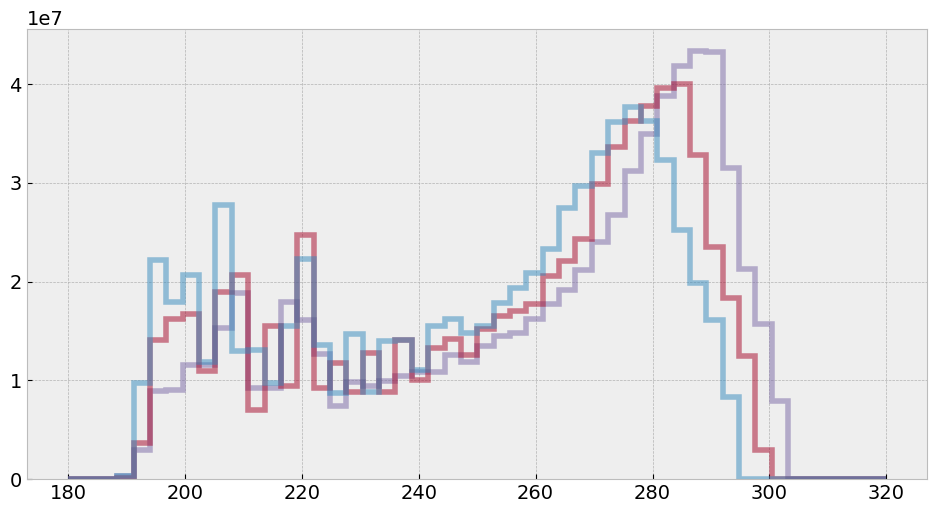

In [8]:
temp_hist = multi_experiment_variables_subset['Temperature'].stats.histogram(dims=['time', 'plev', 'lat', 'lon'], bins=50, range=[180, 320])

SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = fig.add_gridspec(1, 1, wspace=0.3)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

ax = []
ax.append(fig.add_subplot(gs[0]))

left, bottom, width, height = [0.255, 0.65, 0.17, 0.25]

for index, experiment in enumerate(coords.experiments.values):
    ax[0].stairs(
        temp_hist['counts'].sel(experiment=experiment),
        temp_hist['bin_edges'],
        alpha=0.5,
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        zorder=4-index,
        linewidth = 4
    )
    
plt.show()

In [5]:
multi_experiment_variables_subset['Total Column Water'] = (
    multi_experiment_variables_subset['Total Cloud Condensate']
    + 1000*(1/1000)*config.LIQUID_WATER_DENSITY*multi_experiment_variables_subset['Column Water Vapor']
)
multi_experiment_variables_subset['Total Column Water'].name = 'Total Column Water'
multi_experiment_variables_subset['Total Column Water'].attrs['short_name'] = 'TCW'
multi_experiment_variables_subset['Total Column Water'].attrs['units'] = 'g m$^{-2}$'

# Interpolate variables to a temperature level

In [5]:
# Define a function that interpolates a variable to a specific temperature level
def temperature_level_interpolation(variable_to_interpolate, interpolation_temperature):

    if 'Temperature' not in multi_experiment_variables_subset:
        raise KeyError("'Temperature' not found in 'multi_experiment_variables_subset'")

    # If the variable is a cloud-related property, select temperature data excluding the first time step
    # Otherwise, use the full temperature dataset
    if variable_to_interpolate.name in ['Cloud Ice Water Content', 'Cloud Liquid Water Content', 'Cloud Fraction', 'Cloud Condensate']:
        temperature_array = multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None))
    else:
        temperature_array = multi_experiment_variables_subset['Temperature']

    # Create a boolean mask identifying where temperature exceeds the interpolation threshold
    interpolation_mask = temperature_array > interpolation_temperature
    # Find the index of the first pressure level where temperature exceeds the threshold (argmax returns first True)
    index_of_interpolation_temperature = interpolation_mask.argmax(dim='plev')                
    
    # Extract the pressure level at the warmer (first exceeding) temperature threshold
    # Where no threshold is exceeded, the value is set to NaN via the where() condition
    warmer_pressure_level = temperature_array['plev'].isel(plev=index_of_interpolation_temperature).where(interpolation_mask.any(dim='plev')) 
    # Extract the pressure level just below the threshold (one level colder)
    colder_pressure_level = temperature_array['plev'].isel(plev=index_of_interpolation_temperature-1).where(interpolation_mask.any(dim='plev'))     

    # Get the actual temperature values at the warmer pressure level for use in interpolation
    temperature_at_warmer_pressure_level = temperature_array.sel(plev=warmer_pressure_level)
    # Get the actual temperature values at the colder pressure level for use in interpolation
    temperature_at_colder_pressure_level = temperature_array.sel(plev=colder_pressure_level)

    # Get the variable values at the warmer pressure level
    variable_at_warmer_pressure_level = variable_to_interpolate.sel(plev=warmer_pressure_level)
    # Get the variable values at the colder pressure level
    variable_at_colder_pressure_level = variable_to_interpolate.sel(plev=colder_pressure_level)

    # Perform linear interpolation to find the pressure level at the exact interpolation temperature
    # Formula: plev = plev_warm + (plev_cold - plev_warm) * (T_interp - T_warm) / (T_cold - T_warm)
    plev_at_interpolation_temperature = (
        warmer_pressure_level 
        + (colder_pressure_level - warmer_pressure_level)*(interpolation_temperature - temperature_at_warmer_pressure_level)/(temperature_at_colder_pressure_level - temperature_at_warmer_pressure_level)
    )

    # Perform linear interpolation to find the variable value at the exact interpolation temperature
    # Uses the same linear interpolation principle applied to the variable of interest
    variable_at_interpolation_temperature = (
        variable_at_warmer_pressure_level 
        + (variable_at_colder_pressure_level - variable_at_warmer_pressure_level)*(plev_at_interpolation_temperature - warmer_pressure_level)/(colder_pressure_level - warmer_pressure_level)
    )

    # Return the interpolated variable value at the specified temperature level
    return plev_at_interpolation_temperature, variable_at_interpolation_temperature

In [10]:
# logger.info("Interpolating variable to 220K level...")
# _, cloud_ice_water_content_at_220K = temperature_level_interpolation(multi_experiment_variables_subset['Cloud Ice Water Content'], 220)
# cloud_ice_water_content_at_220K.name = 'Cloud Ice Water Content at 220K'
# cloud_ice_water_content_at_220K.attrs['units'] = 'g m$^{-2}$'

# _, cloud_liquid_water_content_at_220K = temperature_level_interpolation(multi_experiment_variables_subset['Cloud Liquid Water Content'], 220)
# cloud_liquid_water_content_at_220K.name = 'Cloud Liquid Water Content at 220K'
# cloud_liquid_water_content_at_220K.attrs['units'] = 'g m$^{-2}$'

_, cloud_fraction_at_220K = temperature_level_interpolation(multi_experiment_variables_subset['Cloud Fraction'], 220)
cloud_fraction_at_220K.name = 'Cloud Fraction at 220K'
cloud_fraction_at_220K.attrs['units'] = ''

# Joint Histograms

## Calculate components

In [157]:
# Analysis parameters
remove_climatology = False
center_on_zero = False

N = np.size(multi_experiment_variables_subset['Precipitation'].sel(experiment='4K').values)
t_critical = t.ppf(0.95, df=N-2)

#### Specify numerator variable
numerator_variable = cloud_fraction_at_220K
# numerator_variable = multi_experiment_variables_subset['Cloud Ice Water Path']
# numerator_variable = multi_experiment_variables_subset['Cloud Liquid Water Path']
# numerator_variable = multi_experiment_variables_subset['Total Column Water']
# numerator_variable = multi_experiment_variables_subset['Total Cloud Condensate']
# numerator_variable = multi_experiment_variables_subset['Outgoing Longwave Radiation']
# numerator_variable = 1000*cloud_liquid_water_content_at_220K

#### Specify denominator variable
denominator_variable = multi_experiment_variables_subset['Cloud Ice Water Path']
# denominator_variable = multi_experiment_variables_subset['Cloud Liquid Water Path']
# denominator_variable = multi_experiment_variables_subset['Precipitation'].units.to_energy_units()
# denominator_variable = (1/1000)*config.LIQUID_WATER_DENSITY*multi_experiment_variables_subset['Column Water Vapor']
# denominator_variable.attrs['units'] = 'g m$^{-2}$'
# denominator_variable = multi_experiment_variables_subset['Total Cloud Condensate']
# denominator_variable = multi_experiment_variables_subset['Total Column Water']
# denominator_variable = cloud_ice_water_content_at_220K

logger.info(f"Numerator: {numerator_variable.name}")
logger.info(f"Denominator: {denominator_variable.name}")

if remove_climatology:
    logger.info("Removing climatology")
    numerator_variable = numerator_variable.stats.standardize()
    denominator_variable = denominator_variable.stats.standardize()

numerator_variable = numerator_variable.where(coords.latitude_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
denominator_variable = denominator_variable.where(coords.latitude_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))

if center_on_zero:
    logger.info("Centering histogram on origin")
    denominator_variable = denominator_variable.stats.standardize(dim='grid_points')
    numerator_variable = numerator_variable.stats.standardize(dim='grid_points')

    # r_estimate = xr.zeros_like(experiments_array).astype('float64')
    # r_intercept = xr.zeros_like(experiments_array).astype('float64')
    # for experiment_index, experiment in enumerate(experiments_list):
    #     r_estimate[experiment_index], r_intercept[experiment_index] = np.polyfit(
    #         y=r_numerator.sel(experiment=experiment).dropna(dim='grid_points'),
    #         x=r_denominator.sel(experiment=experiment).dropna(dim='grid_points'),
    #         deg=1
    #     )
    #     predicted_value = r_estimate[experiment_index] * r_denominator.sel(experiment=experiment).dropna(dim='grid_points')
    #     residual_sum_of_squares = ((r_estimate[experiment_index] - predicted_value) ** 2).sum(dim=['grid_points'])
    #     residual_variance = residual_sum_of_squares / (N - 2)
    #     standard_error_slope = np.sqrt(residual_variance / (N - 1))
    #     t_statistic = r_estimate[experiment_index] / standard_error_slope

counts,xbins,ybins = {}, {}, {}
logger.info("Calculating bins and counts")
for index, experiment in enumerate(coords.experiments.values):
    logger.info(f"    Experiment {config.EXPERIMENT_DISPLAY_NAMES[experiment]}...")
    mask = ~np.isnan(denominator_variable.sel(experiment=experiment)) & ~np.isnan(numerator_variable.sel(experiment=experiment))

    counts[experiment],xbins[experiment],ybins[experiment] = np.histogram2d(
        x=denominator_variable.sel(experiment=experiment).where(mask, drop=True),
        y=numerator_variable.sel(experiment=experiment).where(mask, drop=True),
        bins=[100, 100],
    )

logger.info("Finished")

2026-05-07 16:39:08,885 [INFO] Numerator: Cloud Fraction at 220K
2026-05-07 16:39:08,887 [INFO] Denominator: Cloud Ice Water Path


2026-05-07 16:39:09,759 [INFO] Calculating bins and counts
2026-05-07 16:39:09,761 [INFO]     Experiment −4K...
2026-05-07 16:39:21,730 [INFO]     Experiment CTRL...
2026-05-07 16:39:29,275 [INFO]     Experiment +4K...
2026-05-07 16:39:39,879 [INFO] Finished


## Plot

/glade/derecho/scratch/sressel/tmp/ipykernel_27429/1218250486.py:27: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts[experiment].transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_27429/1218250486.py:46: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts[experiment].transpose()),
2026-05-07 16:40:25,227 [INFO] Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//histograms
2026-05-07 16:40:25,230 [INFO] Output filename: Cloud Fraction at 220K & Cloud Ice Water Path - Log(Histogram)
2026-05-07 16:40:25,237 [INFO] Saving...                              
2026-05-07 16:40:26,119 [INFO] ✔ Saved successfully


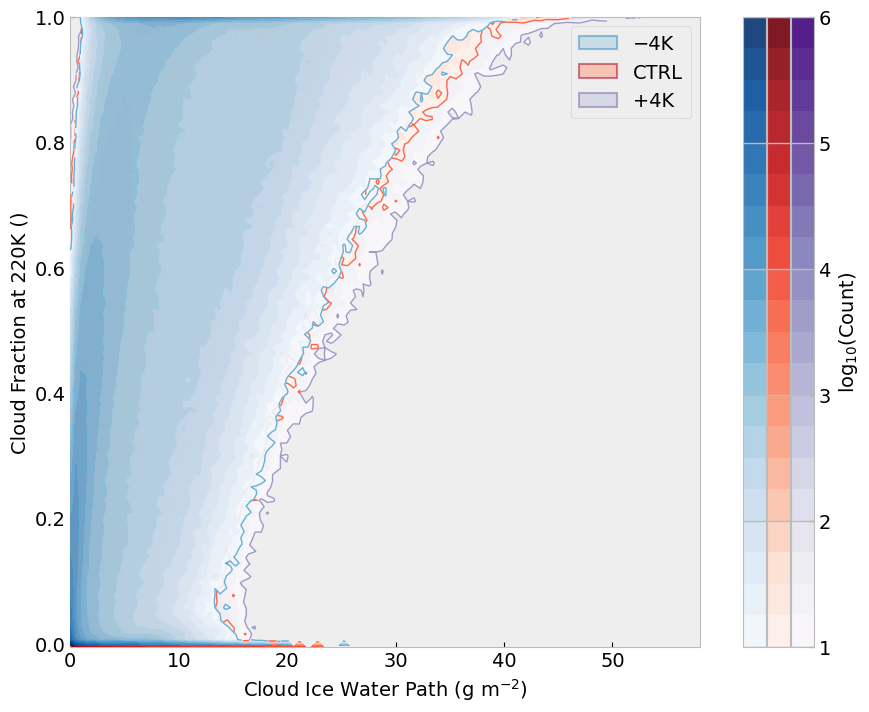

In [159]:
SAVE_FIG = True
PLOT_MODE = "slides"
FIG_LAYOUT = 'full'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = fig.add_gridspec(1, 2, wspace=0.1, width_ratios=[0.9, 1-0.9])
gs.update(left=0.05, right=0.8, bottom=0.05, top=0.95)

ax = fig.add_subplot(gs[0])

gs_cbars = gs[1].subgridspec(1, 3, wspace=0.05)
cbar_axes = [
    fig.add_subplot(gs_cbars[0]),
    fig.add_subplot(gs_cbars[1]),
    fig.add_subplot(gs_cbars[2]),
]

# Create legend with median color for each experiment
legend_elements = []

# ax.set_title(f'{string.ascii_letters[ax_index]}) {dict_name}', loc='left', pad=5, fontsize=fontsize+2)
for index, experiment in enumerate(coords.experiments.values):
    im = ax.contourf(
        np.log10(counts[experiment].transpose()),
        extent=[xbins[experiment][0],xbins[experiment][-1],ybins[experiment][0],ybins[experiment][-1]],
        cmap=config.EXPERIMENT_CMAPS[experiment],
        levels=np.linspace(np.log10(10), 6, 21),
        alpha=0.9,
        zorder = 4-index,
    )

    legend_elements.append(
        plt.Rectangle(
            (0, 0), 1, 1,
            facecolor=plt.get_cmap(config.EXPERIMENT_CMAPS[experiment])(0.35),
            edgecolor=bmh_colors(index+1),
            alpha=0.5,
            linewidth=1.5,
            label=config.EXPERIMENT_DISPLAY_NAMES[experiment])
        )

    ax.contour(
        np.log10(counts[experiment].transpose()),
        extent=[xbins[experiment][0],xbins[experiment][-1],ybins[experiment][0],ybins[experiment][-1]],
        levels = [im.levels[0]],
        colors = plt.get_cmap(config.EXPERIMENT_CMAPS[experiment])(0.5),
        # colors=bmh_colors(index+1),
        zorder = 4-index,
        linewidths=1
    )

    # ax.plot(
    #         r_denominator.sel(experiment=experiment),
    #         (r_estimate*r_denominator+r_intercept).sel(experiment=experiment),
    #         color=bmh_colors(index+1),
    #         lw=3,
    #         label=f"{experiments_array.sel(experiment=experiment)['name'].item():<4} (r={-r_estimate.sel(experiment=experiment):>1.2f})",
    #         zorder=10,
    #     )

    # ax.axhline(y=0, color='gray', ls=':', zorder=10)
    # ax.axvline(x=0, color='gray', ls=':', zorder=10)
    #     

    cbar = fig.colorbar(im, cax=cbar_axes[index])
    [cbar.ax.axhline(y=val, color='#bcbcbc', lw=1) for val in np.arange(1, 7, 1)]
    if experiment == '4K':
        cbar.set_ticks(np.arange(1, 7, 1))
        cbar.set_label(r"log$_{10}$(Count)")
    else:
        cbar.set_ticks([])

ax.grid(False)
ax.set_xlabel(f"{denominator_variable.name} ({denominator_variable.attrs['units']})")
ax.set_ylabel(f"{numerator_variable.name} ({numerator_variable.attrs['units']})")

# ax.set_xlim(0, 1.1*denominator_variable.max())
# ax.set_ylim(0, 1.1*numerator_variable.max())

# ax.set_xlim(0, 825)
# ax.set_ylim(0, 55)

ax.set_aspect((ax.get_xlim()[1] - ax.get_xlim()[0])/(ax.get_ylim()[1] - ax.get_ylim()[0]))
ax.legend(handles=legend_elements, loc='upper right')

# Save figure
output_filename = f"{numerator_variable.name}{(' Anomalies' if remove_climatology else '')} & {denominator_variable.name}{(' Anomalies' if remove_climatology else '')} - Log(Histogram)"
logger.info(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms")
logger.info(f"Output filename: {output_filename}")

if SAVE_FIG:
    logger.info(f"{'Saving...':<{config.SEP_WIDTH-1}}")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    logger.info("✔ Saved successfully")
else:
    logger.info("Not saving")

plt.show()

# Bin Variables

## Bin by Temperature

In [ ]:
# olr_mask = (
#     multi_experiment_variables_subset['Outgoing Longwave Radiation']
#     <= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.05, dim=['time', 'lat', 'lon'])
# )

# olr_mask = (
#     multi_experiment_variables_subset['Outgoing Longwave Radiation']
#     >= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.8, dim=['time', 'lat', 'lon'])
# )

binning_variable_by_temperature = {}

recalculate = True
normalize_binning_variable = True

temperature_bins = np.arange(180, 320, 5)  # adjust as needed
# bins = np.arange(200, 240, 4)  # adjust as needed

# print("Bin Variables by Temperature")
logger.info("Bin Variables by Temperature")
for binning_variable in [
    # 'Clear Sky Radiative Cooling',
    # 'Cloud Ice Water Content',
    # 'Divergence',
    'Cloud Fraction',
    # 'Cloud Condensate',
    # 'Relative Humidity'
]:
    binning_variable_by_temperature[binning_variable] = xr.DataArray(
        data = np.zeros((len(coords.experiments), len(temperature_bins[:-1]))),
        dims=['experiment', 'temperature'],
        coords={'experiment':coords.experiments, 'temperature':temperature_bins[:-1]}
    )
    logger.info("=" * config.SEP_WIDTH)
    logger.info(f"{binning_variable}...")

    if 'binning_variable_by_temperature' not in locals() or recalculate:

        for index, experiment in enumerate(coords.experiments.values):

            if binning_variable in ['Cloud Ice Water Content', 'Cloud Liquid Water Content', 'Cloud Fraction', 'Cloud Condensate']:
                temperature = multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None)).sel(
                    experiment=experiment, plev=slice(100, 950), lat=slice(-15,15)
                )#.mean(dim=['lat', 'lon'])

            else:
                temperature = multi_experiment_variables_subset['Temperature'].sel(
                    experiment=experiment, plev=slice(100, 950), lat=slice(-15,15)
                )#.mean(dim=['lat', 'lon'])

            binning_variable_subset = multi_experiment_variables_subset[binning_variable].sel(
                experiment=experiment, plev=slice(100, 950), lat=slice(-15,15)
            )#.mean(dim=['lat', 'lon'])

            temperature_flat = temperature.values.flatten()
            binning_variable_flat = binning_variable_subset.values.flatten()

            mask = np.isfinite(temperature_flat) & np.isfinite(binning_variable_flat)

            temperature_flat = temperature_flat[mask]
            binning_variable_flat = binning_variable_flat[mask]

            digitized = np.digitize(temperature_flat, temperature_bins)

            binning_variable_by_temperature[binning_variable][index, :] = [
                np.nanmean(binning_variable_flat[digitized == i])
                if np.any(digitized == i)
                else np.nan
                for i in range(1, len(temperature_bins))
            ]

    logger.info("✔ Done")

logger.info("=" * config.SEP_WIDTH)
logger.info("Finished")

2026-05-07 19:59:37,258 [INFO] Bin Variables by Temperature
2026-05-07 19:59:37,261 [INFO] ========================================
2026-05-07 19:59:37,261 [INFO] Cloud Fraction...


2026-05-07 20:00:25,061 [INFO] ✔ Done
2026-05-07 20:00:25,063 [INFO] ========================================
2026-05-07 20:00:25,065 [INFO] Finished


### Plot

2026-04-20 14:51:49,713 [INFO] Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//
2026-04-20 14:51:49,717 [INFO] Output filename: Cloud Fraction by Temperature - High OLR
2026-04-20 14:51:49,718 [INFO] Not saving


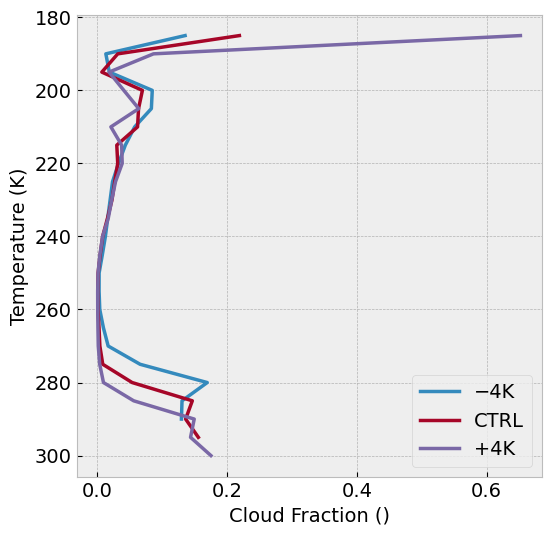

In [20]:
# binning_variable_to_plot = 'Cloud Ice Water Content'
# binning_variable_to_plot = 'Cloud Condensate'
# binning_variable_to_plot = 'Divergence'
binning_variable_to_plot = 'Cloud Fraction'
# binning_variable_to_plot = 'Relative Humidity'

SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'square'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)

[fig, ax] = plt.subplots(
    figsize=get_figsize(PLOT_MODE, FIG_LAYOUT)
)

for index, experiment in enumerate(coords.experiments.values):
    ax.plot(
        (
            binning_variable_by_temperature[binning_variable_to_plot].sel(experiment=experiment)
            # / binning_variable_by_temperature[binning_variable_to_plot].sel(experiment=experiment).max(dim=['temperature'])
        ),
        # np.gradient(binning_variable_by_temperature[experiment], bins[:-1]),
        binning_variable_by_temperature[binning_variable_to_plot].temperature,
        color=bmh_colors(index+1),
        label = config.EXPERIMENT_DISPLAY_NAMES[experiment],
    )

# ax.set_xlabel(
#     f"{('Normalized' if binning_variable_by_temperature[binning_variable_to_plot].attrs['normalized'] else '')} \n{binning_variable_to_plot}"
#     f" ({(multi_experiment_variables_subset[binning_variable_to_plot].attrs['units'] if not binning_variable_by_temperature[binning_variable].attrs['normalized'] else '')})",
# )
# ax.set_xlabel(
#     f"Normalized \n{binning_variable_to_plot}",
# )
ax.set_xlabel(
    f"{binning_variable_to_plot} ({multi_experiment_variables_subset[binning_variable_to_plot].attrs['units']})",
)
ax.set_ylabel("Temperature (K)")
ax.legend(loc='best')
ax.invert_yaxis()

output_filename = f"{binning_variable_to_plot} by Temperature - High OLR"
logger.info(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/")
logger.info(f"Output filename: {output_filename}")

if SAVE_FIG:
    logger.info(f"{'Saving...':<{config.SEP_WIDTH-1}}")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    logger.info("✔ Saved successfully")
else:
    logger.info("Not saving")

plt.show()

In [ ]:
latitude_bounds = xr.DataArray(
    # [[-5, -10, -15], [5, 10, 15]],
    # [[-30, -30, -30], [30, 30, 30]],
    [[-15, -15, -15], [15, 15, 15]],
    dims=["bound", "experiment"],
    coords={"bound":['lower', 'upper'], "experiment": experiments_array}
)

latitude_mask = (
    (multi_experiment_variables_subset['Precipitation'].lat >= latitude_bounds.sel(bound='lower')) &
    (multi_experiment_variables_subset['Precipitation'].lat <= latitude_bounds.sel(bound='upper'))
)

experiment_cmaps = {}
experiment_cmaps['-4K'] = 'Blues'
experiment_cmaps['0K'] = 'Reds'
experiment_cmaps['4K'] = 'Purples'
fontsize = 14
plt.style.use('default')
plt.rcParams.update({'font.size':fontsize})
plt.rcParams['mathtext.fontset'] = 'dejavusans'
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 3, wspace=0.3)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

ax= fig.add_subplot(gs[0])

olr_anomalies = standardize_data(multi_experiment_variables_subset['Outgoing Longwave Radiation'], dim='time', unit_variance=False).isel(time=slice(1, None))
# emissivity_anomalies = standardize_data(emissivity, dim='time', unit_variance=False)

numerator = olr_anomalies.where(latitude_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
# denominator = emissivity_anomalies.where(latitude_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
denominator = emissivity.where(latitude_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
    
numerator = standardize_data(numerator, dim='grid_points', unit_variance=False)
# denominator = standardize_data(denominator, dim='grid_points', unit_variance=False)

for index, experiment in enumerate(experiments_list):

    counts,xbins,ybins = np.histogram2d(
        x = denominator.sel(experiment=experiment).dropna(dim='grid_points'),
        y = numerator.sel(experiment=experiment).dropna(dim='grid_points'),
        bins=[100,100]
    )
    im = ax.contourf(
        np.log10(counts.transpose()),
        # counts.transpose(),
        extent=[xbins[0],xbins[-1],ybins[0],ybins[-1]],
        cmap=experiment_cmaps[experiment],
        # colors=experiment_cmaps[experiment],
        # levels = np.linspace(10, np.nanmax(counts), 21),
        levels=np.linspace(np.log10(10), 6, 21),
        alpha=0.9,
        zorder = 4-index
    )

ax.set_ylim(-175, 125)
# ax.set_xlim(-500, 2500)
ax.set_xlim(0, 1)
# ax.invert_xaxis()
ax.set_aspect((ax.get_xlim()[1] - ax.get_xlim()[0])/(ax.get_ylim()[1] - ax.get_ylim()[0]))
    
plt.show()

In [ ]:
ice_water_path_layer = (25*100/9.8)*multi_experiment_variables_subset['Cloud Ice Water Content']
liquid_water_path_layer = (25*100/9.8)*multi_experiment_variables_subset['Cloud Liquid Water Content']

# tau_lw_layer = 0.08*1000*liquid_water_path_layer + 0.04*1000*ice_water_path_layer
tau_lw_layer = 1*1000*liquid_water_path_layer + 1*1000*ice_water_path_layer
tau_lw = tau_lw_layer.sum(dim='plev')
emissivity = 1 - np.exp(-tau_lw)

multi_experiment_variables_subset['Emissivity'] = emissivity

binning_variable_by_emissivity = {}

recalculate = True
normalize_binning_variable = True

# bins = np.arange(180, 320, 5)  # adjust as needed
bins = np.arange(0.01, 1.05, 0.05)
# bins = np.arange(200, 240, 4)  # adjust as needed

print("Bin Variables by Emissivity")
for binning_variable in [
    # 'Clear Sky Radiative Cooling',
    # 'Cloud Ice Water Content',
    # 'Divergence',
    # 'Cloud Fraction',
    'Outgoing Longwave Radiation',
    # 'Relative Humidity'
]:
    binning_variable_by_emissivity[binning_variable] = xr.DataArray(
        data = np.zeros((3, len(bins[:-1]))),
        dims=['experiment', 'emissivity'],
        coords={'experiment':experiments_array, 'emissivity':bins[:-1]}
    )
    print(f"{'='*config.SEP_WIDTH}")
    print(f"{f'{binning_variable}...':<{config.SEP_WIDTH}}")
    if 'binning_variable_by_emissivity' not in locals() or recalculate:

        for index, experiment in enumerate(experiments_list):
            
            domain_mean_emissivity = multi_experiment_variables_subset['Emissivity'].sel(
                experiment=experiment, lat=slice(-15,15)
            )#.mean(dim=['lat', 'lon'])
            emissivity_flat = domain_mean_emissivity.values.flatten()

            # domain_mean_binning_variable = standardize_data(multi_experiment_variables_subset[binning_variable], 'time', False).sel(
            #     experiment=experiment, lat=slice(-15,15)
            # ).isel(time=slice(1, None))
            domain_mean_binning_variable = multi_experiment_variables_subset[binning_variable].sel(
                experiment=experiment, lat=slice(-15,15)
            ).isel(time=slice(1, None))
        
            binning_variable_flat = domain_mean_binning_variable.values.flatten()

            mask = np.isfinite(emissivity_flat) & np.isfinite(binning_variable_flat)

            emissivity_flat = emissivity_flat[mask]
            binning_variable_flat = binning_variable_flat[mask]

            # emissivity bins
            digitized = np.digitize(emissivity_flat, bins)

            binning_variable_by_emissivity[binning_variable][index, :] = [
                np.nanmean(binning_variable_flat[digitized == i])
                if np.any(digitized == i)
                else np.nan
                for i in range(1, len(bins))
            ]

    print(rf"{'✔':>1}")

print(f"{'='*config.SEP_WIDTH}")
print("Finished")

Bin Variables by Emissivity
Outgoing Longwave Radiation...          
✔
Finished


Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//mean-state/
Output filename: Normalized Outgoing Longwave Radiation by Emissivity
Not Saving


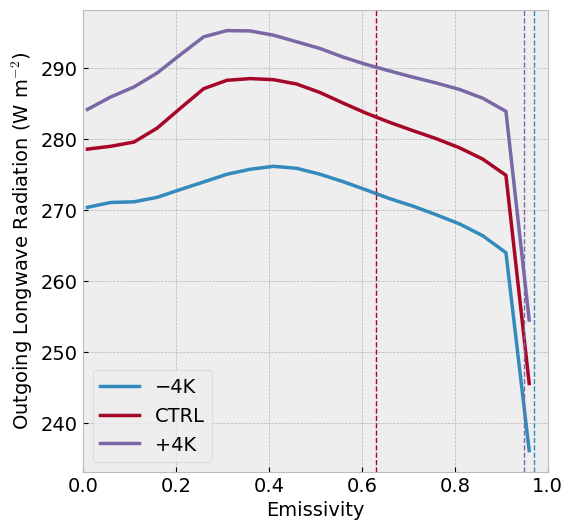

In [ ]:
# binning_variable_to_plot = 'Cloud Ice Water Content'
binning_variable_to_plot = 'Outgoing Longwave Radiation'
# binning_variable_to_plot = 'Divergence'
# binning_variable_to_plot = 'Cloud Fraction'
# binning_variable_to_plot = 'Relative Humidity'

SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'square'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)

[fig, ax] = plt.subplots(
    figsize=get_figsize(PLOT_MODE, FIG_LAYOUT)
)

for index, experiment in enumerate(experiments_list):
    ax.plot(
        binning_variable_by_emissivity[binning_variable_to_plot].emissivity,
        (
            binning_variable_by_emissivity[binning_variable_to_plot].sel(experiment=experiment)
            # / binning_variable_by_emissivity[binning_variable_to_plot].sel(experiment=experiment).max(dim=['emissivity'])
            # / binning_variable_by_emissivity[binning_variable_to_plot].sel(experiment=experiment).isel(emissivity=-1)
        ),
        color=bmh_colors(index+1),
        label = experiments_array.sel(experiment=experiment)['name'].item(),
    )
    ax.axvline(
        emissivity.sel(experiment=experiment).mean(dim=['time', 'lat', 'lon']),
        color=bmh_colors(index+1),
        ls='--',
        lw=1,
        # label=f"{experiments_array.sel(experiment=experiment)['name'].item()} Mean Emissivity"
        )

# ax.set_xlabel(
#     f"{('Normalized' if binning_variable_by_temperature[binning_variable_to_plot].attrs['normalized'] else '')} \n{binning_variable_to_plot}"
#     f" ({(multi_experiment_variables_subset[binning_variable_to_plot].attrs['units'] if not binning_variable_by_temperature[binning_variable].attrs['normalized'] else '')})",
# )
# ax.set_xlabel(
#     f"Normalized \n{binning_variable_to_plot}",
# )
ax.set_ylabel(
    f"{binning_variable_to_plot} ({multi_experiment_variables_subset[binning_variable_to_plot].attrs['units']})",
)
ax.set_xlabel("Emissivity")
ax.set_xlim(0, 1)
ax.legend(loc='best')

output_filename = f'Normalized {binning_variable_to_plot} by Emissivity'
print(f"Output directory: {aquaplanet_output_directory}/mean-state/")
print(f"Output filename: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/mean-state/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()

In [ ]:
multi_experiment_variables_subset['Outgoing Longwave Radiation'].min(dim=['time', 'lat', 'lon'])

<xarray.DataArray 'Outgoing Longwave Radiation' (experiment: 3)> Size: 12B
array([118.61256, 117.47035, 119.32674], dtype=float32)
Coordinates:
  * experiment  (experiment) <U3 36B '-4K' '0K' '4K'
Attributes:
    Sampling_Sequence:  rad_lwsw
    units:              tt
    long_name:          Upwelling longwave flux at top of model
    cell_methods:       time: mean
    description:        Outgoing longwave radiation at TOA
    file_id:            OLR
    short_name:         OLR
    subset:             True

In [162]:
0.9*(5.67*10**-8)*(220)**4

119.54083680000001

In [ ]:
# if 'clear_sky_radiative_cooling' not in locals():
#     cloud_condensate_specific_humidity = multi_experiment_variables_subset['Cloud Ice Water Content'] + multi_experiment_variables_subset['Cloud Liquid Water Content']
#     cloudy_cells = cloud_condensate_specific_humidity > 1e-5
#     clear_sky_cells = cloud_condensate_specific_humidity <= 1e-5
#     clear_sky_radiative_cooling = multi_experiment_variables_subset['Longwave Heating Rate'].where(clear_sky_cells)
#     clear_sky_radiative_cooling.sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon'], skipna=True).plot(y='plev', yincrease=False, hue='experiment')

#     multi_experiment_variables_subset['Clear Sky Radiative Cooling'] = clear_sky_radiative_cooling
#     multi_experiment_variables_subset['Clear Sky Radiative Cooling'].attrs['units'] = r'W m$^{-2}$'

# multi_experiment_variables_subset['Cloud Condensate'] = (
#     multi_experiment_variables_subset['Cloud Ice Water Content'] + multi_experiment_variables_subset['Cloud Liquid Water Content']
# )

# olr_mask = (
#     multi_experiment_variables_subset['Outgoing Longwave Radiation']
#     <= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.05, dim=['time', 'lat', 'lon'])
# )

olr_mask = (
    multi_experiment_variables_subset['Outgoing Longwave Radiation']
    >= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.8, dim=['time', 'lat', 'lon'])
)

binning_variable_by_precipitation = {}

recalculate = True
normalize_binning_variable = True

# bins = np.arange(180, 320, 5)  # adjust as needed
bins = np.arange(180, 320, 5)  # adjust as needed
# bins = np.arange(200, 240, 4)  # adjust as needed

# print("Bin Variables by precipitation")
logger.info("Bin Variables by precipitation")
for binning_variable in [
    # 'Clear Sky Radiative Cooling',
    # 'Cloud Ice Water Content',
    # 'Divergence',
    'Cloud Fraction',
    # 'Cloud Condensate',
    # 'Relative Humidity'
]:
    binning_variable_by_precipitation[binning_variable] = xr.DataArray(
        data = np.zeros((len(coords.experiments), len(bins[:-1]))),
        dims=['experiment', 'precipitation'],
        coords={'experiment':coords.experiments, 'precipitation':bins[:-1]}
    )
    logger.info("=" * config.SEP_WIDTH)
    logger.info(f"{binning_variable}...")

    if 'binning_variable_by_precipitation' not in locals() or recalculate:

        for index, experiment in enumerate(coords.experiments.values):

            if binning_variable in ['Cloud Ice Water Content', 'Cloud Liquid Water Content', 'Cloud Fraction', 'Cloud Condensate']:
                precipitation = multi_experiment_variables_subset['precipitation'].isel(time=slice(1, None)).where(olr_mask, drop=True).sel(
                    experiment=experiment, plev=slice(100, 950), lat=slice(-15,15)
                )#.mean(dim=['lat', 'lon'])

            else:
                precipitation = multi_experiment_variables_subset['precipitation'].where(olr_mask, drop=True).sel(
                    experiment=experiment, lat=slice(-15,15)
                )#.mean(dim=['lat', 'lon'])

            binning_variable_subset = multi_experiment_variables_subset[binning_variable].where(olr_mask, drop=True).sel(
                experiment=experiment, plev=slice(100, 950), lat=slice(-15,15)
            )#.mean(dim=['lat', 'lon'])

            precipitation_flat = precipitation.values.flatten()
            binning_variable_flat = binning_variable_subset.values.flatten()

            mask = np.isfinite(precipitation_flat) & np.isfinite(binning_variable_flat)

            precipitation_flat = precipitation_flat[mask]
            binning_variable_flat = binning_variable_flat[mask]

            digitized = np.digitize(precipitation_flat, bins)

            binning_variable_by_precipitation[binning_variable][index, :] = [
                np.nanmean(binning_variable_flat[digitized == i])
                if np.any(digitized == i)
                else np.nan
                for i in range(1, len(bins))
            ]

    logger.info("✔ Done")

logger.info("=" * config.SEP_WIDTH)
logger.info("Finished")

In [ ]:
multi_experiment_variables_subset['Cloud Liquid Water Content'].plev.diff(dim='plev')

In [ ]:
multi_experiment_variables_subset['Precipitation'].quantile(0.05, dim=['time', 'lat', 'lon'])

## Bin Cloud Fraction by Temperature and Cloud Ice Water Path

### Bin OLR by CIWP

In [269]:
cloud_ice_water_path_bins = np.arange(0, 75, 5)
temperature_bins = np.arange(190, 310, 5)
latitude_bounds = slice(-15,15)

binned_olr = xr.DataArray(
    data=np.zeros((len(coords.experiments), len(cloud_ice_water_path_bins)-1)),
    dims=['experiment', 'cloud_ice_water_path'],
    coords={'experiment':coords.experiments, 'cloud_ice_water_path':0.5*(cloud_ice_water_path_bins[1:]+cloud_ice_water_path_bins[:-1])}
)

for index, experiment in enumerate(coords.experiments.values):
    mask = ~np.isnan(multi_experiment_variables_subset['Cloud Ice Water Path'].sel(experiment=experiment, lat=latitude_bounds)) & ~np.isnan(multi_experiment_variables_subset['Outgoing Longwave Radiation'].sel(experiment=experiment, lat=latitude_bounds))

    [binned_olr_by_experiment, bin_edges, binnumber] = stats.binned_statistic(
        x=multi_experiment_variables_subset['Cloud Ice Water Path'].sel(experiment=experiment, lat=latitude_bounds).where(mask, drop=True).values.flatten(),
        values = multi_experiment_variables_subset['Outgoing Longwave Radiation'].sel(experiment=experiment, lat=latitude_bounds).where(mask, drop=True).values.flatten(),
        bins=cloud_ice_water_path_bins
    )
    binned_olr[index, :] = binned_olr_by_experiment

In [270]:
binned_cloud_fraction = xr.DataArray(
    data=np.zeros((len(coords.experiments), len(temperature_bins)-1, len(cloud_ice_water_path_bins)-1)),
    dims=("experiment", "temperature", "cloud_ice_water_path"),
    coords={
        "experiment": coords.experiments,
        "temperature": 0.5 * (temperature_bins[:-1] + temperature_bins[1:]),
        "cloud_ice_water_path": 0.5 * (cloud_ice_water_path_bins[:-1] + cloud_ice_water_path_bins[1:]),
    },
    name="cloud_fraction_binned"
)

stacked_cloud_ice_water_path = multi_experiment_variables_subset['Cloud Ice Water Path'].expand_dims(plev=coords.pressure_levels).sel(lat=latitude_bounds, plev=slice(100, 950)).stack(samples=('time', 'plev', 'lat', 'lon'))

stacked_temperature = multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None)).sel(lat=latitude_bounds, plev=slice(100, 950)).stack(samples=('time', 'plev', 'lat', 'lon'))

stacked_cloud_fraction = multi_experiment_variables_subset['Cloud Fraction'].sel(lat=latitude_bounds, plev=slice(100, 950)).stack(samples=('time', 'plev', 'lat', 'lon'))

logger.info("Bin Cloud Fraction by CIWP and Temperature")
for index, experiment in enumerate(coords.experiments.values):
    logger.info(f"    Experiment {config.EXPERIMENT_DISPLAY_NAMES[experiment]}...")

    cloud_ice_water_path_digitized = np.digitize(stacked_cloud_ice_water_path.sel(experiment=experiment), bins=cloud_ice_water_path_bins, right=True)
    temperature_digitized = np.digitize(stacked_temperature.sel(experiment=experiment), bins=temperature_bins, right=True)
    binned_cloud_fraction[index] = np.array(
        [
            [
                stacked_cloud_fraction.sel(experiment=experiment)[(temperature_digitized == i) & (cloud_ice_water_path_digitized == j)].mean(dim='samples', skipna=True) 
                for i in range(1, len(temperature_bins))
                ] for j in range(1, len(cloud_ice_water_path_bins))
            ]
    ).T

logger.info("Finished")

2026-05-08 11:56:05,920 [INFO] Bin Cloud Fraction by CIWP and Temperature
2026-05-08 11:56:05,932 [INFO]     Experiment −4K...
2026-05-08 11:58:41,190 [INFO]     Experiment CTRL...
2026-05-08 12:01:09,801 [INFO]     Experiment +4K...
2026-05-08 12:06:10,344 [INFO] Finished


2026-05-08 12:10:13,228 [INFO] Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//histograms
2026-05-08 12:10:13,266 [INFO] Output filename: Cloud Fraction binned by Temperature and Cloud Ice Water Path
2026-05-08 12:10:13,267 [INFO] Not saving


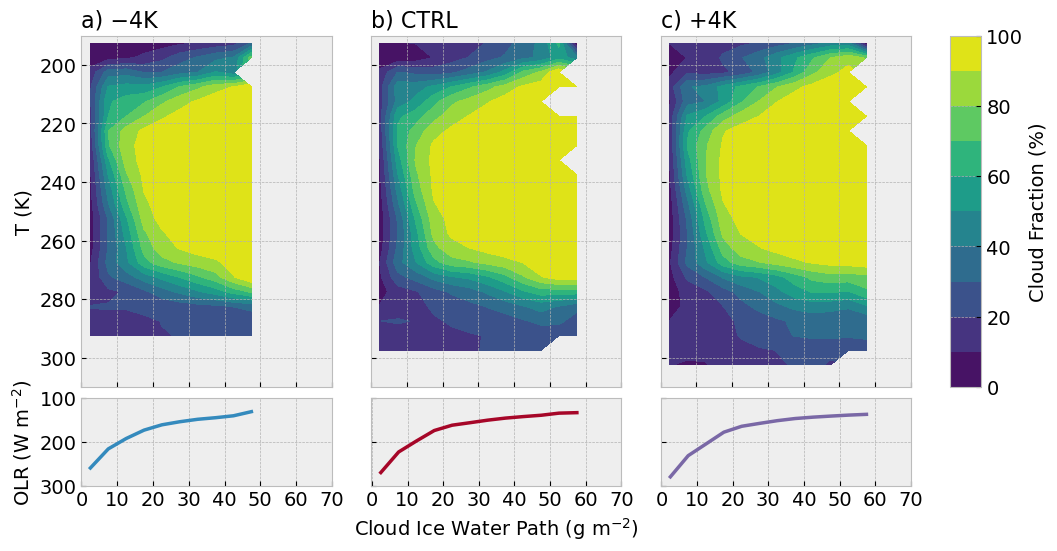

In [290]:
SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = GridSpec(2, 4, figure=fig,  width_ratios = [32, 32, 32, 4], height_ratios=[80,20])
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, wspace=0.2, hspace=0.05)

cloud_fraction_ax = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
]

olr_ax = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
]

cbar_ax = fig.add_subplot(gs[0, 3])

for index, experiment in enumerate(coords.experiments.values):

    cloud_fraction_ax[index].set_title(
        f'{string.ascii_letters[index]}) {config.EXPERIMENT_DISPLAY_NAMES[experiment]}',
        loc='left',
    )
    im = cloud_fraction_ax[index].contourf(
        binned_cloud_fraction.cloud_ice_water_path,
        binned_cloud_fraction.temperature,
        100*binned_cloud_fraction.sel(experiment=experiment),
        levels=np.linspace(0, 100, 11), 
        cmap='viridis'
        # cmap=config.EXPERIMENT_CMAPS[experiment]
    )
    cloud_fraction_ax[index].set_xlim(0, 70)
    cloud_fraction_ax[index].set_xticks(np.arange(0, 80, 10))

    cloud_fraction_ax[index].set_ylim(190, 310)
    cloud_fraction_ax[index].invert_yaxis()
    cloud_fraction_ax[index].set_xticklabels('')

    olr_ax[index].plot(
        binned_olr.cloud_ice_water_path,
        binned_olr.sel(experiment=experiment),
        color=bmh_colors(index+1)
    )

    # olr_ax[index].axhline(
    #     y=config.STEFAN_BOLTZMANN_CONSTANT*220**4,
    #     ls=':',
    #     color='k',
    #     linewidth=2
    # )

    # cloud_fraction_ax[index].set_xlim(
    #     binned_olr.sel(experiment=experiment)[binned_olr.sel(experiment=experiment).argmax()].cloud_ice_water_path,
    #     binned_olr.sel(experiment=experiment)[binned_olr.sel(experiment=experiment).argmin()].cloud_ice_water_path
    # )

    # # olr_ax[index].set_xlim(0, 70)
    # olr_ax[index].set_xlim(
    #     binned_olr.sel(experiment=experiment)[binned_olr.sel(experiment=experiment).argmax()].cloud_ice_water_path,
    #     binned_olr.sel(experiment=experiment)[binned_olr.sel(experiment=experiment).argmin()].cloud_ice_water_path
    # )
    olr_ax[index].set_xticks(np.arange(0, 80, 10))
    olr_ax[1].set_xlabel(r"Cloud Ice Water Path (g m$^{-2}$)")
    olr_ax[index].set_ylim(100, 300)
    olr_ax[index].invert_yaxis()

    if index == 0:
        cloud_fraction_ax[index].set_ylabel(r"T (K)")
        olr_ax[index].set_ylabel(r"OLR (W m$^{-2}$)")

    else:
        cloud_fraction_ax[index].set_yticklabels('')
        olr_ax[index].set_yticklabels('')


cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Cloud Fraction (%)')

output_filename = f"Cloud Fraction binned by Temperature and Cloud Ice Water Path"
logger.info(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms")
logger.info(f"Output filename: {output_filename}")

if SAVE_FIG:
    logger.info(f"{'Saving...':<{config.SEP_WIDTH-1}}")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    logger.info("✔ Saved successfully")
else:
    logger.info("Not saving")

plt.show()

# Emissivity vs. LWP

Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//
Output filename: Emissivity as a function of Liquid Water Path
Not Saving


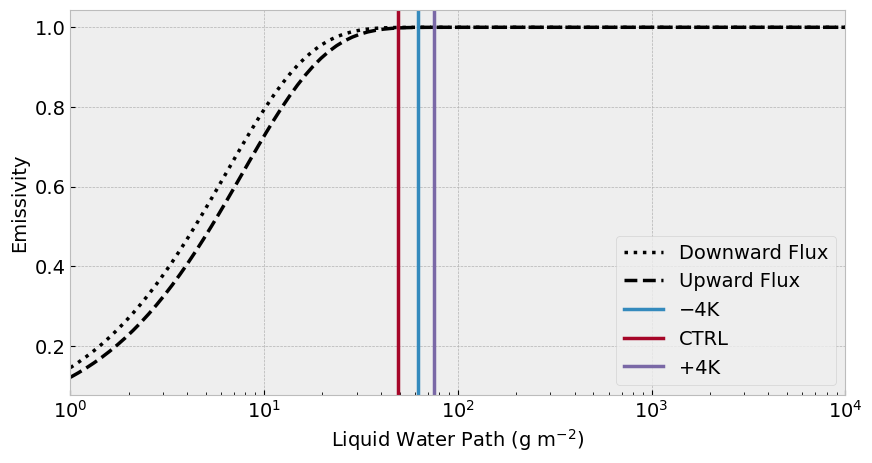

In [6]:
olr_mask = (
    multi_experiment_variables_subset['Outgoing Longwave Radiation']
    <= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.005, dim=['time', 'lat', 'lon'])
)

# mask = (
#     multi_experiment_variables_subset['Outgoing Longwave Radiation']
#     >= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.8, dim=['time', 'lat', 'lon'])
# )

# mask = multi_experiment_variables_subset['Precipitation'] >= multi_experiment_variables_subset['Precipitation'].sel(lat=slice(-15,15)).quantile(0, dim=['time', 'lat', 'lon'])

# cloud_fraction_mask = cloud_fraction_at_220K >= cloud_fraction_at_220K.quantile(0.8, dim=['time', 'lat', 'lon'])
# mask = cloud_fraction_at_220K <= cloud_fraction_at_220K.quantile(0.2, dim=['time', 'lat', 'lon'])

mask = olr_mask 

liquid_water_paths = xr.DataArray(
    np.logspace(0, 4, 100),
    dims=['liquid_water_path'],
    coords={'liquid_water_path': np.logspace(0, 4, 100)}
)
stephens_param_down = 1 - np.exp(-0.158*liquid_water_paths)
stephens_param_up = 1 - np.exp(-0.13*liquid_water_paths)

SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
ax = fig.add_subplot()

ax.plot(liquid_water_paths, stephens_param_down, color='k', ls=':', label='Downward Flux')
ax.plot(liquid_water_paths, stephens_param_up, color='k', ls='--', label='Upward Flux')
for index, experiment in enumerate(coords.experiments.values):
    ax.axvline(
        1000*multi_experiment_variables_subset['Cloud Liquid Water Path'].where(mask).sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon']).sel(experiment=experiment),
        color=bmh_colors(index+1),
        label = config.EXPERIMENT_DISPLAY_NAMES[experiment]
    )
ax.set_xlabel(r'Liquid Water Path (g m$^{-2}$)')
ax.set_ylabel('Emissivity')
ax.set_xlim(1, 10000)
ax.set_xticks([1, 10, 100, 1000, 10000])
ax.set_xscale('log')
ax.legend(loc='lower right')

output_filename = 'Emissivity as a function of Liquid Water Path'
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/")
print(f"Output filename: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()

Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//
Output filename: Emissivity as a function of Ice Water Path
Not Saving


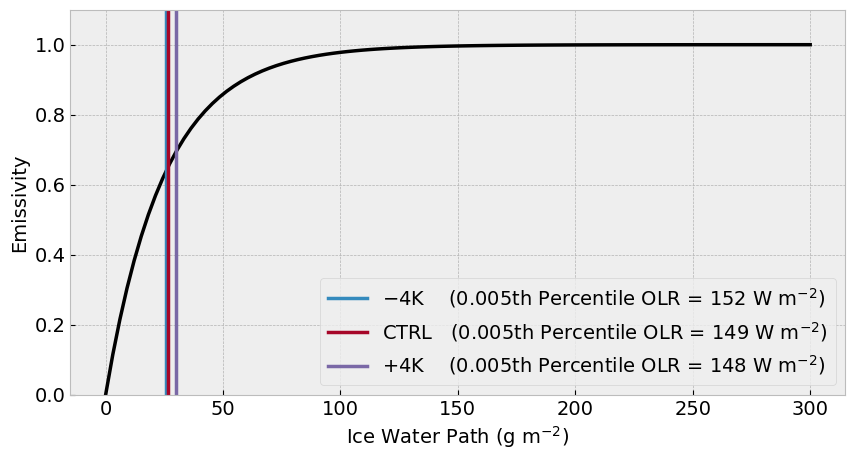

In [7]:
diffusivity_factor = 1.66
effective_radius = 50
# lambda_vals = np.array([4.1,5,6.1,7,8.1,9.1,10,11.1,12.2,14.1,16.1,18.2,20,25,31,37,50,75,100,167])
# alpha = np.array(
#     [0.0048,0.0054,0.0005,0.0013,0.003,0.0038,0.0043,0.0003,-0.0013,-0.002,0,0.0028,0.0044,0.0077,0.0074,0.0043,-0.0004,0.0072,0.011,0.0099])
# gamma = np.array(
#     [0.69,0.626,1.279,1.193,1.021,0.949,0.911,1.29,1.452,1.558,1.388,1.099,0.92,0.366,0.603,1.014,1.604,0.926,0.34,0.001]
# )

i = [1,2,3,4,5]
alpha = np.array([0.002, 0.0016, 0.0003, 0.0068, 0.0036])
gamma = np.array([1.118, 1.166, 1.338, 0.600, 1.136])

weights = xr.DataArray(
    data=np.array([0.040, 0.200, 0.340, 0.281, 0.139]),
    dims=['wavelength_band'],
    coords={'wavelength_band': i}
)

kappa = xr.DataArray(
    data=(alpha + gamma/effective_radius),
    dims=['wavelength_band'],
    coords={'wavelength_band': i}
)
ice_water_paths = xr.DataArray(
    data=np.linspace(0, 300, 100),
    dims=["ice_water_path"],
    coords={'ice_water_path': np.linspace(0, 300, 100)}
)

parameterized_emissivity = (1 - np.exp(-diffusivity_factor*kappa*ice_water_paths)).weighted(weights).mean(dim='wavelength_band')

# olr_mask = (
#     multi_experiment_variables_subset['Outgoing Longwave Radiation']
#     <= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.005, dim=['time', 'lat', 'lon'])
# )

_, CIWC_at_220K = temperature_level_interpolation(multi_experiment_variables_subset['Cloud Ice Water Content'], 220)
# ciwc_mask = (
#     CIWC_at_220K <= CIWC_at_220K.quantile(.1, dim=['time', 'lat', 'lon'])
# )

olr_mask = (
    multi_experiment_variables_subset['Outgoing Longwave Radiation']
    <= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.005, dim=['time', 'lat', 'lon'])
)

ciwc_mask = (
    CIWC_at_220K >= CIWC_at_220K.quantile(.9999, dim=['time', 'lat', 'lon'])
)

mask = olr_mask# * ciwc_mask 

SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
ax = fig.add_subplot()

ax.plot(ice_water_paths, parameterized_emissivity, color='k', ls='-')
for index, experiment in enumerate(coords.experiments.values):
    ax.axvline(
        1000*multi_experiment_variables_subset['Cloud Ice Water Path'].where(mask, drop=True).sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon']).sel(experiment=experiment),
        color=bmh_colors(index+1),
        label = rf"{config.EXPERIMENT_DISPLAY_NAMES[experiment]:<6s} (0.005th Percentile OLR = {multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.005, dim=['time', 'lat', 'lon']).sel(experiment=experiment).values:0.0f} W m$^{{-2}}$)",
    )

ax.set_xlabel(r'Ice Water Path (g m$^{-2}$)')
ax.set_ylabel('Emissivity')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')

output_filename = 'Emissivity as a function of Ice Water Path'
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/")
print(f"Output filename: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()

In [80]:
estimated_ice_emissivity = 1 - np.exp(-diffusivity_factor*kappa*1000*multi_experiment_variables_subset['Cloud Ice Water Path'].where(mask, drop=True).sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon'])).weighted(weights).mean(dim='wavelength_band')

estimated_liquid_emissivity = 1 - np.exp(-0.13*1000*multi_experiment_variables_subset['Cloud Liquid Water Path'].where(mask, drop=True).sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon']))

# pressure_at_220K, CIWC_at_220K = temperature_level_interpolation(multi_experiment_variables_subset['Cloud Ice Water Content'], 220)

cloud_top_ice_emission = (
    estimated_ice_emissivity 
    * config.STEFAN_BOLTZMANN_CONSTANT 
    * (multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None), plev=0))**4
)

cloud_top_liquid_emission = (
    estimated_liquid_emissivity 
    * config.STEFAN_BOLTZMANN_CONSTANT 
    * (multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None), plev=0))**4
)

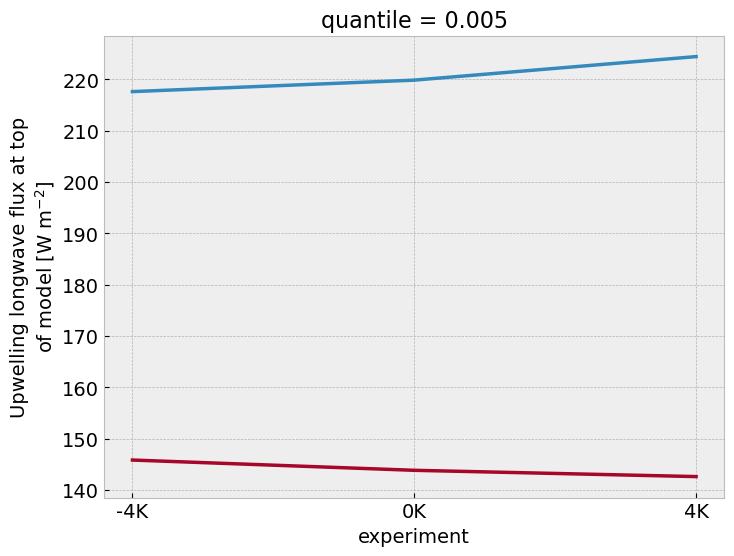

In [81]:
(cloud_top_ice_emission + cloud_top_liquid_emission).mean(dim=['time', 'lat', 'lon'], skipna=True).plot()
(multi_experiment_variables_subset['Outgoing Longwave Radiation']).where(mask, drop=True).sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon'], skipna=True).plot()
# cloud_top_liquid_emission.mean(dim=['time', 'lat', 'lon'], skipna=True).plot()

In [ ]:

weights = xr.DataArray(
    data=np.array([0.040, 0.200, 0.340, 0.281, 0.139]),
    dims=['weights'],
    coords={'weights':weights}
)

kappa = xr.DataArray(
    data=alpha + gamma/effective_radius,
    dims=['weights'],
    coords={'weights':weights}
)

emissivity_by_wavelength = 1 - np.exp(-diffusivity_factor*kappa*1000*multi_experiment_variables_subset['Cloud Ice Water Path'])
cloud_ice_longwave_emissivity = emissivity_by_wavelength.weighted(weights).mean(dim='weights')

pressure_at_220K, CIWC_at_22K = temperature_level_interpolation('Cloud Ice Water Content', 240)

cloud_top_ice_emission = cloud_ice_longwave_emissivity * config.STEFAN_BOLTZMANN_CONSTANT * (multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None)).sel(plev=pressure_at_220K, method='nearest'))**4

cloud_water_longwave_emissivity = 1 - np.exp(-0.13*1000*multi_experiment_variables_subset['Cloud Liquid Water Path'])
cloud_top_water_emission = cloud_water_longwave_emissivity * config.STEFAN_BOLTZMANN_CONSTANT * (multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None)).sel(plev=pressure_at_220K, method='nearest'))**4

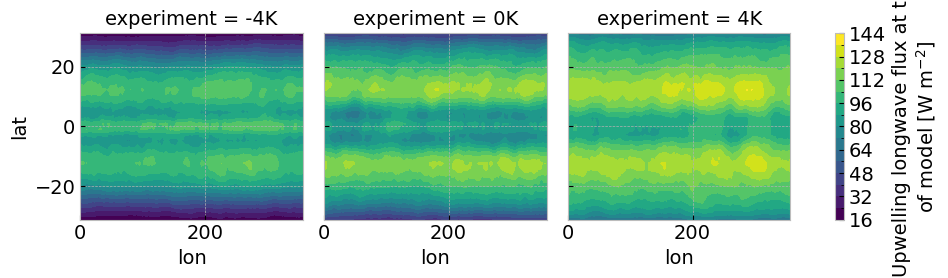

In [42]:
(multi_experiment_variables_subset['Outgoing Longwave Radiation'] - cloud_top_water_emission - cloud_top_ice_emission).mean(dim='time').plot.contourf(x='lon', col='experiment', levels=21)

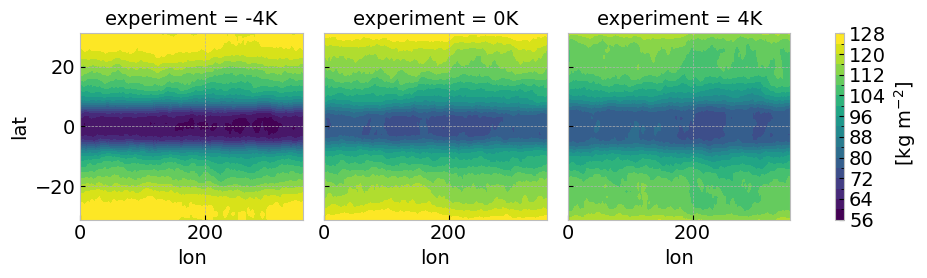

In [40]:
cloud_top_water_emission.mean(dim='time').plot.contourf(x='lon', col='experiment', levels=21)

# Histograms

Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//histograms/
Output filename: OLR & Precipitation Histograms
Not Saving


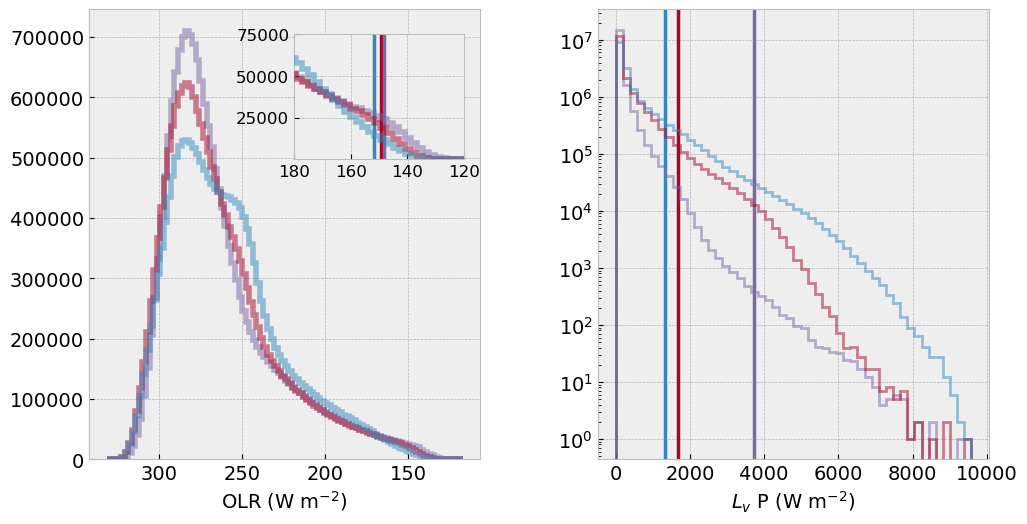

In [67]:
SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = fig.add_gridspec(1, 2, wspace=0.3)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

ax = []
ax.append(fig.add_subplot(gs[0]))
ax.append(fig.add_subplot(gs[1]))

left, bottom, width, height = [0.255, 0.65, 0.17, 0.25]
inset_axis = fig.add_axes([left, bottom, width, height])

olr_hist = multi_experiment_variables_subset['Outgoing Longwave Radiation'].stats.histogram(dims=['time', 'lat', 'lon'], bins=100)
precip_hist = multi_experiment_variables_subset['Precipitation'].units.to_energy_units().stats.histogram(dims=['time', 'lat', 'lon'], bins=50)

for index, experiment in enumerate(coords.experiments.values):
    ax[0].stairs(
        olr_hist['counts'].sel(experiment=experiment),
        olr_hist['bin_edges'],
        alpha=0.5,
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        zorder=4-index,
        linewidth = 4
    )
    
    ax[1].stairs(
        precip_hist['counts'].sel(experiment=experiment),
        precip_hist['bin_edges'],
        alpha=0.5,
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        zorder=4-index,
        linewidth=2,
    )

    ax[1].axvline(
        multi_experiment_variables_subset['Precipitation'].units.to_energy_units().sel(experiment=experiment).quantile(0.9999, dim=['time', 'lat', 'lon']),
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment]
    )

    # ax[0].axvline(
    #     multi_experiment_variables_subset['Outgoing Longwave Radiation'].sel(experiment=experiment).quantile(0.005, dim=['time', 'lat', 'lon']),
    #     color=bmh_colors(index+1),
    #     label=config.EXPERIMENT_DISPLAY_NAMES[experiment]
    # )

    inset_axis.stairs(
        olr_hist['counts'].sel(experiment=experiment),
        olr_hist['bin_edges'],
        alpha=0.5,
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        zorder=4-index,
        linewidth = 4
    )

    inset_axis.axvline(
        multi_experiment_variables_subset['Outgoing Longwave Radiation'].sel(experiment=experiment).quantile(0.005, dim=['time', 'lat', 'lon']),
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment]
    )

ax[0].set_xlabel(r'OLR (W m$^{-2}$)')
ax[1].set_xlabel(r'$L_v$ P (W m$^{-2}$)')

inset_axis.set_xlim([120, 180])
inset_axis.set_xticks([180, 160, 140, 120])
inset_axis.set_ylim([0, 75000])
inset_axis.set_yticks([25000, 50000, 75000])
inset_axis.invert_xaxis()
inset_axis.tick_params(labelsize=12)

# ax0_percentile = inset_axis.secondary_xaxis('top')
# ax0_percentile.set_xticks(
#     olr_percentile_ticks,
#     labels=format_axis_labels(olr_percentile_levels)
#     )
# ax0_percentile.set_xlabel('OLR percentile', fontsize=12)
# ax0_percentile.xaxis.set_ticks_position('top')
# ax0_percentile.xaxis.set_label_position('top')
# ax0_percentile.tick_params(axis='x', labelsize=10, pad=2)
# ax0_percentile.set_xlim(inset_axis.get_xlim())
# if inset_axis.xaxis_inverted():
#     ax0_percentile.invert_xaxis()

# ax[1].loglog()
ax[1].set_yscale('log')
ax[0].invert_xaxis()

output_filename = 'OLR & Precipitation Histograms'
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms/")
print(f"Output filename: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()

[]

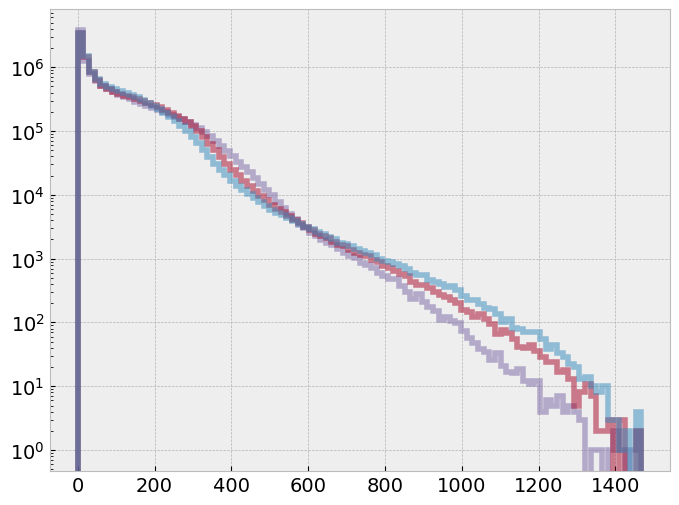

In [66]:
tcc_histogram = multi_experiment_variables_subset['Total Cloud Condensate'].dropna(dim='time').stats.histogram(dims=['time', 'lat', 'lon'], bins=100)
for index, experiment in enumerate(coords.experiments.values):
    plt.stairs(
        tcc_histogram['counts'].sel(experiment=experiment),
        tcc_histogram['bin_edges'],
        alpha=0.5,
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        zorder=4-index,
        linewidth = 4
    )
plt.semilogy()